![ITQ](imgLogo.png)
![ITQ](imgPortada.png)


Luis Pilaguano

##### Predicción de Riesgo de Diabetes con **Regresión Logística** 
La diabetes es una enfermedad crónica que afecta a millones de personas en el mundo. El diagnóstico temprano es crucial para evitar complicaciones graves. En este ejercicio trabajaremos con un conjunto de datos de pacientes para predecir la probabilidad de que una persona tenga diabetes utilizando **Regresión Logística**
## **Dataset**
El archivo contien 15000 registros con las siguientes variables.<br>
1. Pregnancies: Número de embarazos (0 si es hombre).
2. PlasmaGlucose: Nivel de glucosa plasmática en ayunas (mg/dL).
3. DiastolicBloodPressure: Presión arterial diastólica (mmHg).
4. TricepsThickness: Espesor del pliegue cutáneo del tríceps (mm).
5. SerumInsulin: Concentración de insulina en suero (µU/mL).
6. BMI: Índice de masa corporal (kg/m²).
7. DiabetesPedigree: Factor hereditario de riesgo de diabetes.
8. Age: Edad del paciente (años).
9. Diabetic: Variable objetivo (0 = No diabético, 1 = Diabético).
# Instrucciones
Desarrolle el ejercicio paso a paso en un notebook de Jupyter siguiendo las indicaciones:<br>
1. **Lectura y exploración inicial del dataset**
    * Importe el archivo diabetes.csv.
    * Muestre dimensiones, nombres de columnas y distribución de clases.
    * Verifique valores nulos o inconsistencias.
2. **Análisis exploratorio de datos (EDA)**
    * Genere estadísticas descriptivas de las variables numéricas.
    * Dibuje histogramas para al menos 3 variables.
    * Construya la matriz de correlación entre las variables predictoras.
3. **Preparación del dataset**
    * Elimine columnas irrelevantes (ejemplo: PatientID).
    * Divida el dataset en entrenamiento (80%) y prueba (20%) de manera estratificada.
4. **Construcción del modelo**
    * Defina un Pipeline con:
        * StandardScaler para normalizar los datos.
        * LogisticRegression con max_iter=500.
    * Realice validación cruzada (k=5) en el conjunto de entrenamiento.
    * Reporte el AUC-ROC y el AUC-PR de la validación cruzada.
5. **Evaluación del modelo en el conjunto de prueba**
    * Calcule las probabilidades de pertenecer a la clase diabético.
    * Genere la matriz de confusión y el reporte de clasificación.
    * Calcule las métricas: AUC-ROC, AUC-PR, Brier Score.
    * Dibuje las curvas ROC, Precision-Recall y de calibración.    
6. **Selección de umbral**
    * Construya una tabla de métricas para diferentes umbrales (de 0.1 a 0.9).
    * Determine el mejor umbral según el índice de Youden J.
    * Discuta cómo cambia la sensibilidad y la especificidad al modificar el umbral.    
7. **Interpretación del modelo**
    * Liste los coeficientes de la regresión logística.
    * Calcule los odds ratios e interprete al menos dos variables clave.
    * Ejemplo: “Un aumento de 1 unidad en PlasmaGlucose incrementa en X veces la probabilidad de diabetes”.
8. **Predicción con nuevos pacientes**
   * Ingrese manualmente los datos de 2 pacientes ficticios.
   * Calcule la probabilidad de diabetes y la clasificación final para cada u

In [3]:
# ==== Importar librerías y configurar entorno ====
import pandas as pd

## 1. Lectura del dataset

In [25]:
# Intento 1: separador por defecto (',')
df = pd.read_csv('diabetes.csv', sep=';')
# Si todo vino en una sola columna, re-leer con ';'
print(df.head(10))

   PatientID  Pregnancies  PlasmaGlucose  DiastolicBloodPressure  \
0    1354778            0            171                      80   
1    1147438            8             92                      93   
2    1640031            7            115                      47   
3    1883350            9            103                      78   
4    1424119            1             85                      59   
5    1619297            0             82                      92   
6    1660149            0            133                      47   
7    1458769            0             67                      87   
8    1201647            8             80                      95   
9    1403912            1             72                      31   

   TricepsThickness  SerumInsulin        BMI  DiabetesPedigree  Age  Diabetic  
0                34            23  43.509726          1.213191   21         0  
1                47            36  21.240576          0.158365   23         0  
2          

## 2. Limpieza mínima y verificación de clases

In [26]:
# Comprobamos que la columna objetivo exista (Diabetic)
if 'Diabetic' in df.columns:
    print("True")
else: 
    print("False")
# Eliminamos ID si existe
if 'PatientID' in df.columns:
    df = df.drop('PatientID',axis=1)
    print("Columna Eliminada")
else:
    print("Columna no encontrada")


True
Columna Eliminada


In [28]:
# Tipos y valores faltantes
print("DataFrame después de la limpieza:")
df.info()
# Distribución de clases
print(" ------ Distribución de la columna objetivo 'Diabetic':")
print(df['Diabetic'].value_counts())


DataFrame después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Pregnancies             15000 non-null  int64  
 1   PlasmaGlucose           15000 non-null  int64  
 2   DiastolicBloodPressure  15000 non-null  int64  
 3   TricepsThickness        15000 non-null  int64  
 4   SerumInsulin            15000 non-null  int64  
 5   BMI                     15000 non-null  float64
 6   DiabetesPedigree        15000 non-null  float64
 7   Age                     15000 non-null  int64  
 8   Diabetic                15000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 1.0 MB
 ------ Distribución de la columna objetivo 'Diabetic':
Diabetic
0    10000
1     5000
Name: count, dtype: int64


## 3. EDA básico

Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,15000.0,3.224533,3.391020,0.000000,0.000000,2.000000,6.000000,14.000000
PlasmaGlucose,15000.0,107.856867,31.981975,44.000000,84.000000,104.000000,129.000000,192.000000
DiastolicBloodPressure,15000.0,71.220667,16.758716,24.000000,58.000000,72.000000,85.000000,117.000000
TricepsThickness,15000.0,28.814000,14.555716,7.000000,15.000000,31.000000,41.000000,93.000000
SerumInsulin,15000.0,137.852133,133.068252,14.000000,39.000000,83.000000,195.000000,799.000000
BMI,15000.0,31.509646,9.759000,18.200512,21.259887,31.767940,39.259692,56.034628
DiabetesPedigree,15000.0,0.398968,0.377944,0.078044,0.137743,0.200297,0.616285,2.301594
Age,15000.0,30.137733,12.089703,21.000000,22.000000,24.000000,35.000000,77.000000



Histogramas de las variables numéricas:


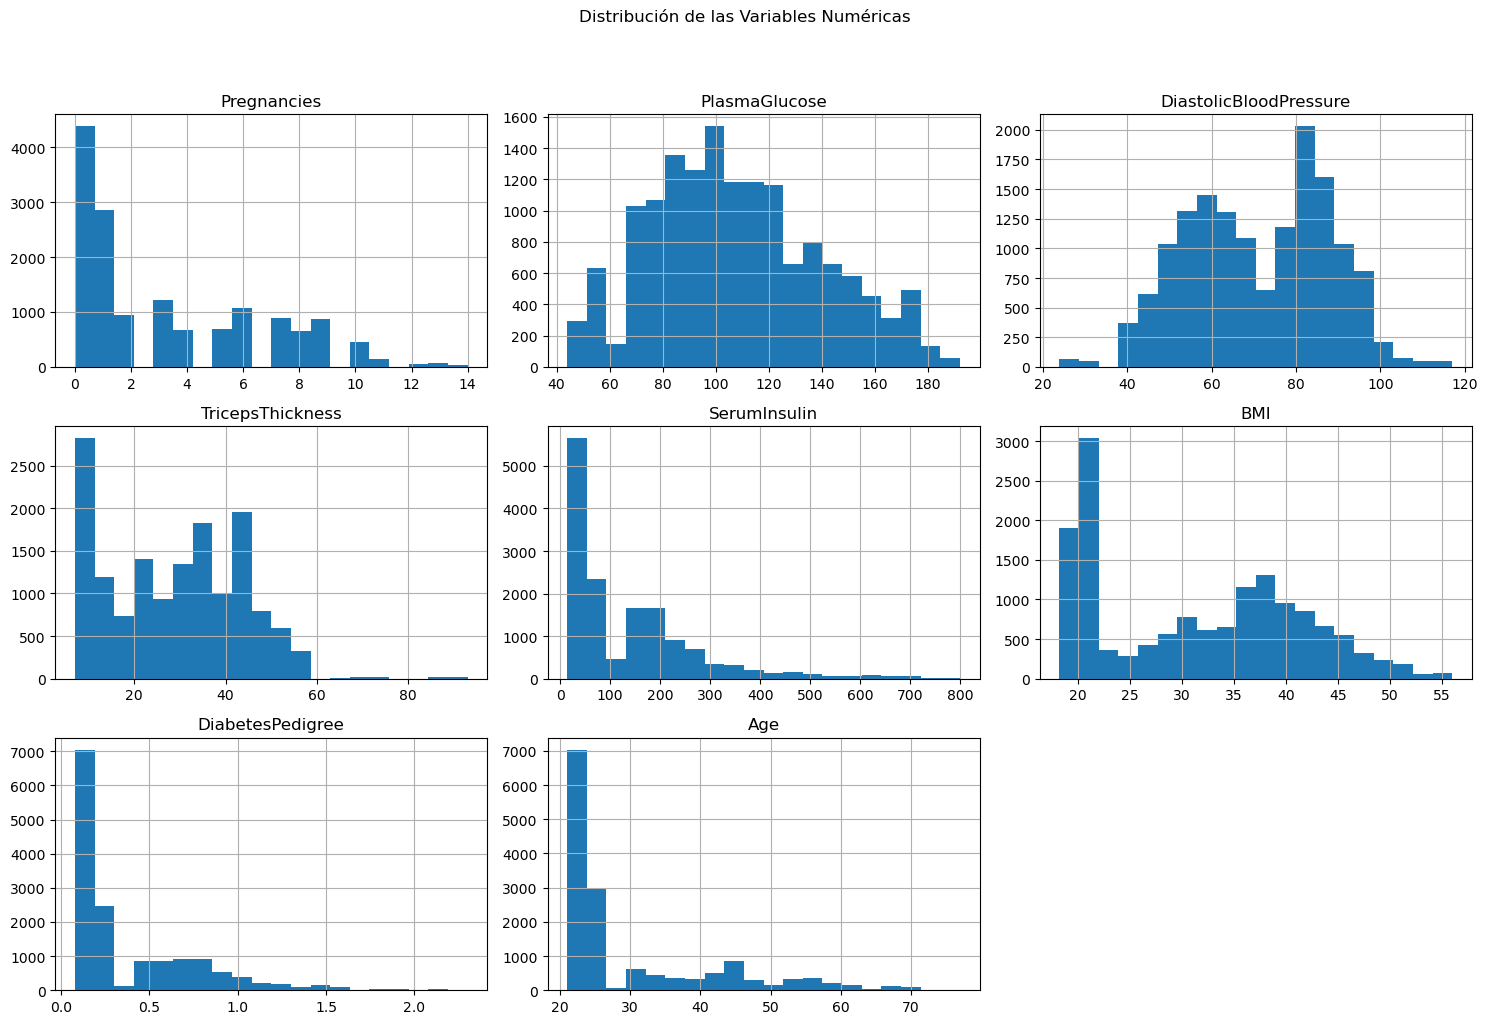

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Definimos la variable objetivo
TARGET = 'Diabetic'

# Obtenemos las columnas numéricas excluyendo la columna objetivo
num_cols = [c for c in df.columns if c != TARGET]

# Mostramos un resumen estadístico de las variables numéricas
print("Resumen estadístico de las variables numéricas:")
display(df[num_cols].describe().T)

# Histograma simple por variable numérica
print("\nHistogramas de las variables numéricas:")
df.hist(column=num_cols, bins=20, figsize=(15, 10))
plt.suptitle('Distribución de las Variables Numéricas', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [31]:
# Calcular la matriz de correlación
correlation_matrix = df.corr()
# Matriz de correlación (sin seaborn)
print("Matriz de Correlación:")
print(correlation_matrix)


Matriz de Correlación:
                        Pregnancies  PlasmaGlucose  DiastolicBloodPressure  \
Pregnancies                1.000000       0.054502                0.043528   
PlasmaGlucose              0.054502       1.000000                0.007212   
DiastolicBloodPressure     0.043528       0.007212                1.000000   
TricepsThickness           0.063605       0.027100                0.011106   
SerumInsulin               0.104487       0.033545                0.022649   
BMI                        0.086386       0.020653                0.015873   
DiabetesPedigree           0.054240       0.009057                0.014099   
Age                        0.136972       0.038864                0.041333   
Diabetic                   0.407315       0.128004                0.091307   

                        TricepsThickness  SerumInsulin       BMI  \
Pregnancies                     0.063605      0.104487  0.086386   
PlasmaGlucose                   0.027100      0.033545  0.02

## 4. Partición Train/Test (estratificada)

In [32]:
from sklearn.model_selection import train_test_split

# Definimos las características (X) y la variable objetivo (y)
TARGET = 'Diabetic'
X = df.drop(TARGET, axis=1)  # Todas las columnas excepto la objetivo
y = df[TARGET]               # Solo la columna objetivo

# Realizamos la partición de los datos
# 'test_size=0.2' reserva el 20% de los datos para la prueba
# 'random_state=42' asegura que la división sea reproducible
# 'stratify=y' es el parámetro clave para que la partición sea estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verificamos las dimensiones de los conjuntos de datos
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (12000, 8)
Dimensiones de y_train: (12000,)
Dimensiones de X_test: (3000, 8)
Dimensiones de y_test: (3000,)


## 5. Pipeline (Scaler + Regresión Logística) y Validación Cruzada

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Creamos el pipeline que encadena el escalado y el modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression())
])

# Realizamos la validación cruzada para evaluar el pipeline
# Usamos 5 'folds' (cv=5) para obtener una evaluación más robusta
# 'scoring="accuracy"' especifica la métrica que nos interesa
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

# Imprimimos los resultados
print("Resultados de la validación cruzada (Accuracy):")
print(scores)
print(f"Accuracy promedio: {scores.mean():.4f}")
print(f"Desviación estándar de la accuracy: {scores.std():.4f}")


Resultados de la validación cruzada (Accuracy):
[0.79208333 0.78125    0.76708333 0.8025     0.78916667]
Accuracy promedio: 0.7864
Desviación estándar de la accuracy: 0.0118


## 6. Entrenamiento final y evaluación en Test

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Escalamos los datos de entrenamiento y prueba
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creamos y entrenamos el modelo de Regresión Logística
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Hacemos predicciones en el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Evaluamos el modelo con varias métricas
print("Evaluación del Modelo en el Conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

# Reporte de clasificación detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
print("Matriz de Confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Evaluación del Modelo en el Conjunto de Prueba:
Accuracy: 0.7883
Precision: 0.7207
Recall: 0.5960
F1-Score: 0.6524

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.88      0.85      2000
           1       0.72      0.60      0.65      1000

    accuracy                           0.79      3000
   macro avg       0.77      0.74      0.75      3000
weighted avg       0.78      0.79      0.78      3000

Matriz de Confusión:
[[1769  231]
 [ 404  596]]


## 7. Curvas ROC y Precision-Recall

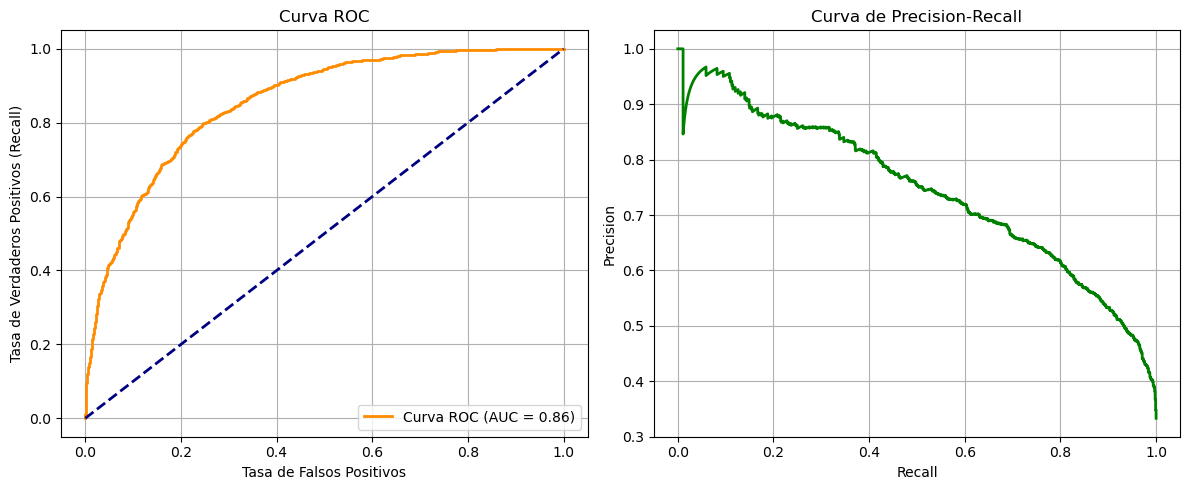

In [35]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción para la clase positiva (1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# --- Curva ROC ---
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)

# --- Curva Precision-Recall ---
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva de Precision-Recall')
plt.grid(True)

plt.tight_layout()
plt.show()


## 8. Calibración y Brier score

Brier Score: 0.1442


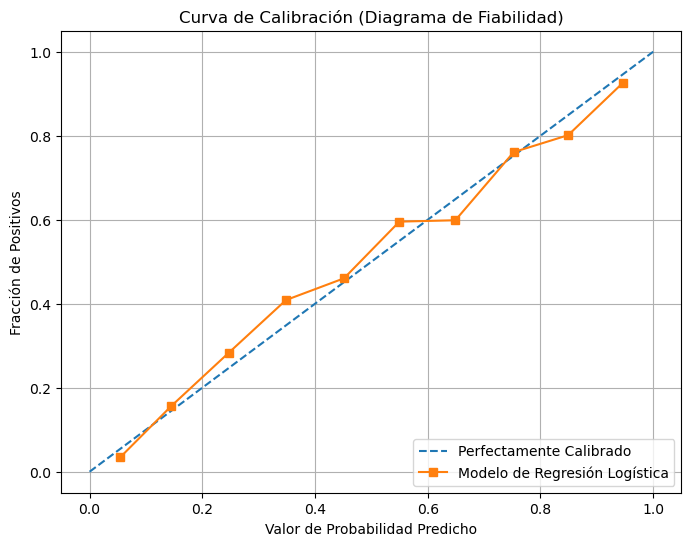

In [38]:

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción para la clase positiva (1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# --- Brier Score ---
brier_score = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier_score:.4f}")

# --- Curva de Calibración ---
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectamente Calibrado')
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"Modelo de Regresión Logística")
plt.xlabel("Valor de Probabilidad Predicho")
plt.ylabel("Fracción de Positivos")
plt.title("Curva de Calibración (Diagrama de Fiabilidad)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 9. Selección de umbral (Youden J y sensibilidad objetivo)

In [39]:

import numpy as np
from sklearn.metrics import roc_curve

# Obtener las probabilidades de predicción para el conjunto de prueba
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calcular la curva ROC para encontrar los umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# --- Método 1: Youden's J ---
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold_youden = thresholds[optimal_idx]

print("--- Umbral Óptimo con Youden's J ---")
print(f"Mejor Umbral: {optimal_threshold_youden:.4f}")
print(f"Sensibilidad (Recall) en este umbral: {tpr[optimal_idx]:.4f}")
print(f"Especificidad en este umbral: {1 - fpr[optimal_idx]:.4f}")

# --- Método 2: Sensibilidad Objetivo (ejemplo con 95%) ---
target_sensitivity = 0.95
idx_target_sensitivity = np.where(tpr >= target_sensitivity)[0][0]
optimal_threshold_target = thresholds[idx_target_sensitivity]

print("\n--- Umbral para Sensibilidad del 95% ---")
print(f"Umbral para Sensibilidad del 95%: {optimal_threshold_target:.4f}")
print(f"Sensibilidad real: {tpr[idx_target_sensitivity]:.4f}")
print(f"Especificidad real: {1 - fpr[idx_target_sensitivity]:.4f}")

--- Umbral Óptimo con Youden's J ---
Mejor Umbral: 0.2913
Sensibilidad (Recall) en este umbral: 0.7990
Especificidad en este umbral: 0.7535

--- Umbral para Sensibilidad del 95% ---
Umbral para Sensibilidad del 95%: 0.1280
Sensibilidad real: 0.9510
Especificidad real: 0.4920


## 10. Interpretación: coeficientes y **odds ratios**

In [40]:
# Recuperar coeficientes de la regresión logística entrenada
import pandas as pd
import numpy as np

# Recuperar los coeficientes del modelo (el modelo está dentro del pipeline)
# Accedemos a los coeficientes del último paso del pipeline
coefficients = model.coef_[0]

# Obtener los nombres de las columnas (características)
features = X_train.columns

# Creamos un DataFrame para una mejor visualización
coef_df = pd.DataFrame({
    'Característica': features,
    'Coeficiente': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

# Ordenar por el valor absoluto del coeficiente para ver las variables más importantes
coef_df['Abs Coef'] = np.abs(coef_df['Coeficiente'])
coef_df = coef_df.sort_values(by='Abs Coef', ascending=False).drop('Abs Coef', axis=1)

print("Análisis de Coeficientes y Odds Ratios:")
print(coef_df)

Análisis de Coeficientes y Odds Ratios:
           Característica  Coeficiente  Odds Ratio
0             Pregnancies     0.921006    2.511815
7                     Age     0.697250    2.008223
4            SerumInsulin     0.510625    1.666332
5                     BMI     0.499743    1.648298
6        DiabetesPedigree     0.379139    1.461027
3        TricepsThickness     0.340428    1.405549
1           PlasmaGlucose     0.296551    1.345212
2  DiastolicBloodPressure     0.201298    1.222989


## 11. Explicabilidad con SHAP (opcional)

In [43]:
# Primero, asegúrate de tener la librería instalada
# !pip install shap

import shap

# Creamos un 'explainer' de SHAP para nuestro modelo de regresión logística
# Usamos el scaler para que SHAP trabaje con los datos escalados que el modelo usa
explainer = shap.Explainer(model, X_train_scaled)

# Calculamos los valores SHAP para el conjunto de prueba
shap_values = explainer(X_test_scaled)

# Graficamos el resumen de los valores SHAP para todas las predicciones
# Un gráfico de abejas ("beeswarm plot") es ideal para esto
print("Resumen de las contribuciones de las características:")
shap.plots.beeswarm(shap_values, max_display=10)

# Para ver el impacto de una sola predicción (por ejemplo, el primer paciente del conjunto de prueba)
print("\nInterpretación de la primera predicción del conjunto de prueba:")
shap.plots.waterfall(shap_values[0])


ModuleNotFoundError: No module named 'shap'

## 12. Guardar modelo y métricas

In [44]:
# Guardar modelo y resumen de métricas

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# 1. Cargar datos
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar modelo
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 3. Guardar modelo
joblib.dump(model, "modelo_randomforest.pkl")


['modelo_randomforest.pkl']

## 13. Verificar el modelo con nuevos datos

[GIT HUB](https://github.com/HLuiss17/Pr-cticas_Aprendizajee_Autom-tico_2/tree/master/Parcial%201)